In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("ipl.csv file.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131.0,5.0,133.0,4.0,Kolkata,Wickets,6.0,Umesh Yadav,MS Dhoni,50.0,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177.0,5.0,179.0,6.0,Delhi,Wickets,4.0,Kuldeep Yadav,Ishan Kishan,81.0,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205.0,2.0,208.0,5.0,Punjab,Wickets,5.0,Odean Smith,Faf du Plessis,88.0,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158.0,6.0,161.0,5.0,Gujarat,Wickets,5.0,Mohammed Shami,Deepak Hooda,55.0,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210.0,6.0,149.0,7.0,Rajasthan,Runs,61.0,Sanju Samson,Aiden Markram,57.0,Yuzvendra Chahal,3--22


Basic Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             53 non-null     int64  
 1   date                 53 non-null     object 
 2   venue                53 non-null     object 
 3   team1                53 non-null     object 
 4   team2                53 non-null     object 
 5   stage                53 non-null     object 
 6   toss_winner          49 non-null     object 
 7   toss_decision        49 non-null     object 
 8   first_ings_score     49 non-null     float64
 9   first_ings_wkts      49 non-null     float64
 10  second_ings_score    49 non-null     float64
 11  second_ings_wkts     49 non-null     float64
 12  match_winner         49 non-null     object 
 13  won_by               49 non-null     object 
 14  margin               49 non-null     float64
 15  player_of_the_match  48 non-null     objec

check the size of rows and columnsof dataset

In [5]:
print("your rows are",df.shape[0],"and columns are",df.shape[1])

your rows are 53 and columns are 20


Now let's see how many columns have null values in total

In [6]:
null_values = df.isna().sum()
null_values

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            4
toss_decision          4
first_ings_score       4
first_ings_wkts        4
second_ings_score      4
second_ings_wkts       4
match_winner           4
won_by                 4
margin                 4
player_of_the_match    5
top_scorer             4
highscore              4
best_bowling           4
best_bowling_figure    4
dtype: int64

Now, Here comes some basic question

1.Which team wons most match?

Text(0.5, 1.0, 'most match by win team')

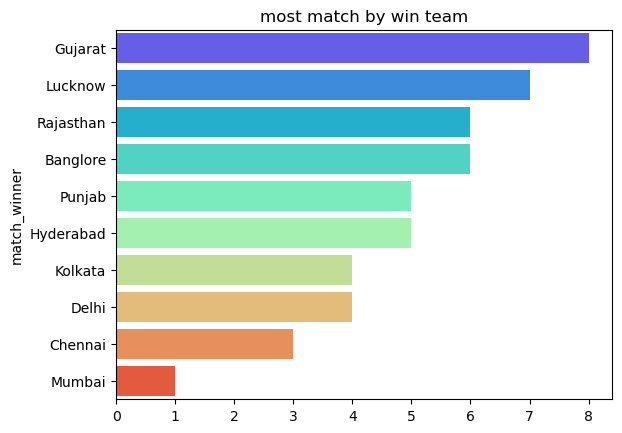

In [7]:
match_wins = df["match_winner"].value_counts()
sns.barplot(x= match_wins.values, y = match_wins.index , palette = "rainbow")
plt.title("most match by win team")

Toss Desicion Trends

Text(0.5, 1.0, 'Decision trends')

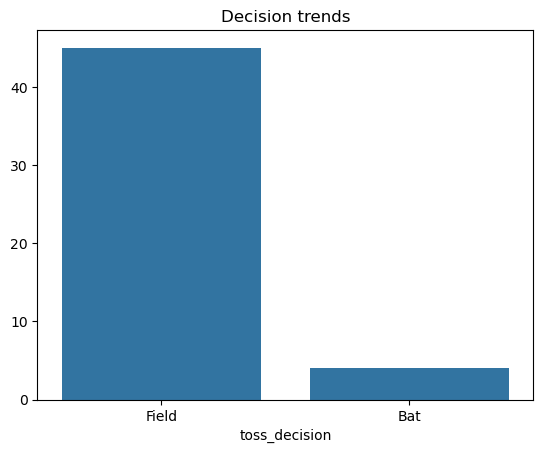

In [8]:
toss_decision = df["toss_decision"].value_counts()
sns.barplot(x = toss_decision.index , y =toss_decision.values)
plt.title("Decision trends")

Toss winner VS Match winner

In [9]:
counts = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()
percentage = (counts*100)/df.shape[0]
percentage.round(2)

np.float64(49.06)

How do team wins? (wickets or runs )

Text(0.5, 1.0, 'match won by')

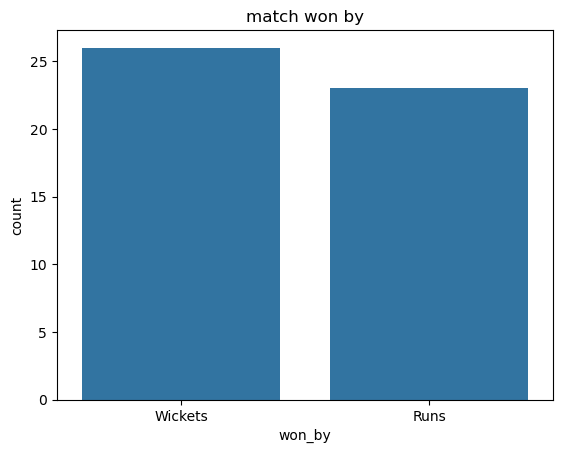

In [10]:
sns.countplot(x = df["won_by"])
plt.title("match won by")

key player performances

1. Most 'player of the Matches'award

Text(0.5, 1.0, 'Top 10 players of match ')

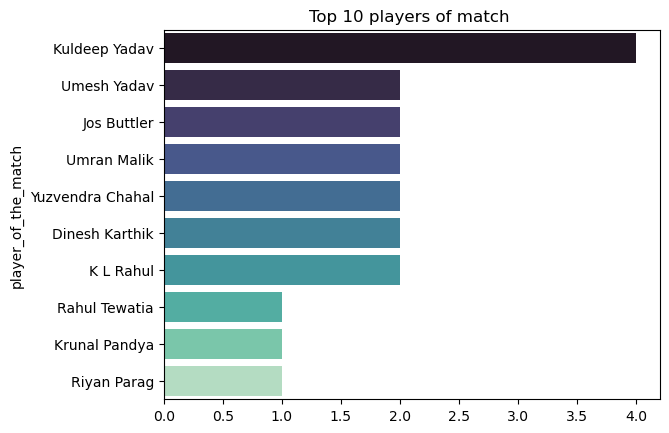

In [11]:
players = df['player_of_the_match'].value_counts().head(10)
sns.barplot(x = players.values , y = players. index , palette = "mako")
plt.title("Top 10 players of match ")

Top scorers

In [12]:
high = df.groupby("top_scorer")['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler    456.0
KL Rahul       351.0
Name: highscore, dtype: float64

Text(0, 0.5, 'highscores')

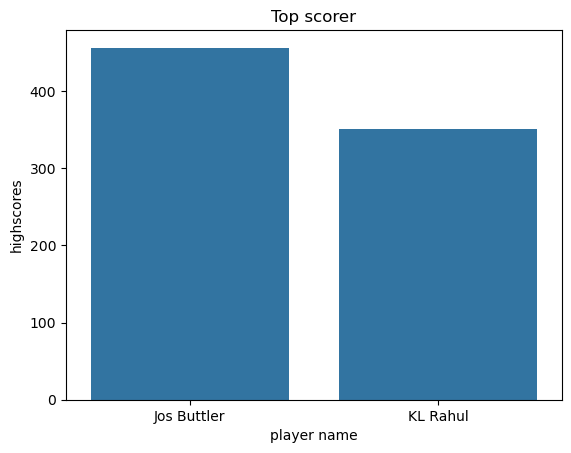

In [13]:
sns.barplot(x = high.index , y = high.values)
plt.title("Top scorer")
plt.xlabel("player name")
plt.ylabel("highscores")

10 Best bowling figure

In [14]:
df['highest_wicket'] = df["best_bowling_figure"].astype(str).apply(lambda x :x.split("--")[0])
df['highest_wicket'] = pd.to_numeric(df['highest_wicket'],errors='coerce')
best_bowler = df.groupby("best_bowling")["highest_wicket"].sum().sort_values(ascending = False).head(10)

<Axes: ylabel='best_bowling'>

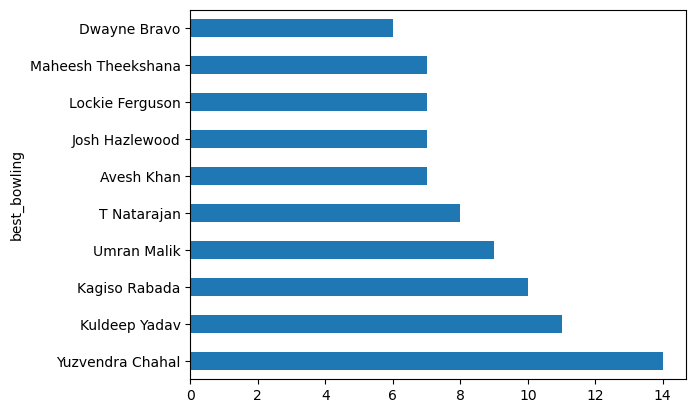

In [15]:
best_bowler.plot(kind = 'barh')

VENUE ANAYSIS

most matches played by venue

Text(0.5, 1.0, 'most matches played by venue')

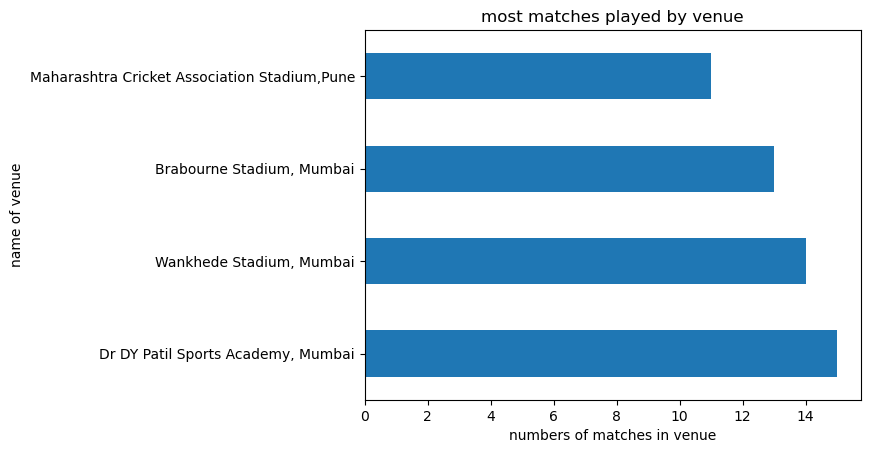

In [16]:
venue= df['venue'].value_counts()
venue.plot(kind = 'barh')
plt.xlabel("numbers of matches in venue")
plt.ylabel("name of venue")
plt.title("most matches played by venue")

Custom Questions & Insights


who won the highest margin by runs?

In [17]:
df[df["won_by"] =='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner' , "margin"]]

,match_winner,margin
4,Rajasthan,61.0


which player had the highest individual score?

In [18]:
df[df['highscore'] == df['highscore'].max()][["player_of_the_match" , "highscore"]]

,player_of_the_match,highscore
33,Jos Buttler,116.0


which bowler had the best bowling figures?

In [21]:
df[df["highest_wicket"]==df['highest_wicket'].max()][['player_of_the_match' , "best_bowling_figure","highest_wicket"]].head(5)

,player_of_the_match,best_bowling_figure,highest_wicket
29,Yuzvendra Chahal,5--40,5.0
39,Umran Malik,5--25,5.0
